# Hands-on AI in Healthcare - Chapter 3: Classical Statistics for Population Health

## 3.1 Setting Up Your Workbench

In this section, we'll confirm that your Python environment is working by loading a real
public health dataset and creating a simple visualization. By the end of this notebook,
you'll have downloaded county-level health data from the County Health Rankings & Roadmaps
project and produced a scatter plot showing how diabetes prevalence relates to household
income across counties in a single U.S. state.

If this notebook runs without errors, your workbench is ready for the rest of the chapter.

### Installing and Importing Libraries

We'll use three libraries throughout this book:

- **pandas** — for loading and manipulating tabular data
- **matplotlib** — for creating charts and visualizations
- **scikit-learn** — for building statistical models (we won't use this yet, but let's
  confirm it's installed)

Run the cell below to install them. If they're already installed, pip will simply report
that the requirement is satisfied.

In [ ]:
# Install the libraries we'll use throughout the book.
# You only need to run this cell once per environment.
%pip install pandas matplotlib scikit-learn openpyxl

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print(f"pandas  : {pd.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print("\nAll libraries loaded successfully!")

pandas  : 3.0.1
matplotlib: 3.10.8
scikit-learn: 1.8.0

All libraries loaded successfully!


### About the Data

The [County Health Rankings & Roadmaps](https://www.countyhealthrankings.org/) project,
a collaboration between the Robert Wood Johnson Foundation and the University of Wisconsin
Population Health Institute, publishes annual county-level health data for every county in
the United States. The dataset includes dozens of measures covering health outcomes, health
behaviors, clinical care, social and economic factors, and the physical environment.

We'll use two measures from this dataset:

- **Diabetes prevalence** — the percentage of adults aged 20 and older with diagnosed diabetes
- **Median household income** — the income level at which half of households earn more
  and half earn less

The data is freely available and requires no login or account to download.

### Downloading the Data

The County Health Rankings publishes its national analytic dataset as a CSV file each year.
Before we can load it, you'll need to download it manually:

1. Visit the County Health Rankings data documentation page at
   [countyhealthrankings.org/health-data/methodology-and-sources/data-documentation](https://www.countyhealthrankings.org/health-data/methodology-and-sources/data-documentation)
2. Find the **National Data** section and download the **analytic data** CSV file
   (the filename will look something like `analytic_data2024.csv`)
3. Place the downloaded file in a folder called `working` next to this notebook

Your file structure should look like this:

```
Chapter 3 Notebook.ipynb
working/
    analytic_data2024.csv
```

The CSV file has a two-row header: the first row contains variable codes (like `v060_rawvalue`),
and the second row contains human-readable descriptions. We'll keep the variable codes as
our column names and skip the description row.

In [6]:
from pathlib import Path
import glob

# Look for the analytic data CSV in the working/ folder.
# This pattern matches any file starting with "analytic_data" so it will
# work regardless of which year's file you downloaded.
csv_files = sorted(glob.glob("working/analytic_data*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "No analytic_data*.csv file found in the working/ folder.\n"
        "Please download the file from countyhealthrankings.org and place it "
        "in a folder called 'working' next to this notebook."
    )

csv_path = csv_files[-1]  # Use the most recent file if multiple are present
print(f"Loading: {csv_path}")

# Read the CSV.
# Row 1, the second row, has computer-friendly variable names (our column names);
# row 0, or the first row, has descriptions that we skip.
# Using encoding="latin-1" handles special characters that occasionally appear in county names.
chr_data = pd.read_csv(
    csv_path,
    header=0,
    skiprows=[0],
    encoding="latin-1",
)

print(f"Dataset shape: {chr_data.shape[0]:,} rows × {chr_data.shape[1]} columns")

Loading: working/analytic_data2024.csv
Dataset shape: 3,195 rows × 770 columns


### Exploring the Data

Before we do anything else, let's look at what we downloaded. This is a habit worth
building — always inspect your data before analyzing it. Even a quick glance can
reveal missing values, unexpected formats, or columns with names you didn't expect.

In [7]:
# Show the first few rows to get a feel for the data.
chr_data.head()

,statecode,countycode,fipscode,state,county,year,county_clustered,v001_rawvalue,v001_numerator,v001_denominator,...,v057_rawvalue,v057_numerator,v057_denominator,v057_cilow,v057_cihigh,v058_rawvalue,v058_numerator,v058_denominator,v058_cilow,v058_cihigh
0,0,0,0,US,United States,2024,NaN,7971.509789,4535347.0,921750763.0,...,0.504081,168004004,333287557,NaN,NaN,0.200031,66300254,331449281,NaN,NaN
1,1,0,1000,AL,Alabama,2024,NaN,11415.734833,98140.0,13812804.0,...,0.513753,2606936,5074296,NaN,NaN,0.422628,2123399,5024279,NaN,NaN
2,1,1,1001,AL,Autauga County,2024,1.0,9407.948438,942.0,159452.0,...,0.512960,30654,59759,NaN,NaN,0.406768,23920,58805,NaN,NaN
3,1,3,1003,AL,Baldwin County,2024,1.0,8981.575353,3789.0,633571.0,...,0.512391,126271,246435,NaN,NaN,0.375865,87113,231767,NaN,NaN
4,1,5,1005,AL,Barbour County,2024,1.0,13138.848362,579.0,68114.0,...,0.471222,11642,24706,NaN,NaN,0.659200,16627,25223,NaN,NaN


In [8]:
# List all column names. This is especially useful with large datasets
# where .head() truncates the display.
print("Number of columns:", len(chr_data.columns))
print()
for col in chr_data.columns:
    print(col)

Number of columns: 770

statecode
countycode
fipscode
state
county
year
county_clustered
v001_rawvalue
v001_numerator
v001_denominator
v001_cilow
v001_cihigh
v001_flag
v001_race_aian
v001_race_aian_cilow
v001_race_aian_cihigh
v001_race_aian_flag
v001_race_asian
v001_race_asian_cilow
v001_race_asian_cihigh
v001_race_asian_flag
v001_race_black
v001_race_black_cilow
v001_race_black_cihigh
v001_race_black_flag
v001_race_hispanic
v001_race_hispanic_cilow
v001_race_hispanic_cihigh
v001_race_hispanic_flag
v001_race_white
v001_race_white_cilow
v001_race_white_cihigh
v001_race_white_flag
v001_race_nhopi
v001_race_nhopi_cilow
v001_race_nhopi_cihigh
v001_race_nhopi_flag
v001_race_tom_flag
v002_rawvalue
v002_numerator
v002_denominator
v002_cilow
v002_cihigh
v036_rawvalue
v036_numerator
v036_denominator
v036_cilow
v036_cihigh
v042_rawvalue
v042_numerator
v042_denominator
v042_cilow
v042_cihigh
v037_rawvalue
v037_numerator
v037_denominator
v037_cilow
v037_cihigh
v037_flag
v037_race_aian
v037_race_ai

The County Health Rankings uses a coding scheme for its variable names. Each health
measure has a number, and the raw value for that measure is stored in a column named
`v{number}_rawvalue`. The columns we need are:

| Column | Description |
|--------|-------------|
| `statecode` | Two-digit state FIPS code |
| `state` | State abbreviation |
| `county` | County name |
| `v060_rawvalue` | Diabetes prevalence (proportion of adults 20+ with diagnosed diabetes) |
| `v063_rawvalue` | Median household income (dollars) |

Let's confirm these columns exist and see what the values look like.

In [9]:
# The columns we'll work with.
DIABETES_COL = "v060_rawvalue"
INCOME_COL = "v063_rawvalue"

# Verify they exist in the dataset.
for col in [DIABETES_COL, INCOME_COL, "state", "county"]:
    if col in chr_data.columns:
        print(f"  ✓  '{col}' found")
    else:
        print(f"  ✗  '{col}' NOT found — check the column list above")

  ✓  'v060_rawvalue' found
  ✓  'v063_rawvalue' found
  ✓  'state' found
  ✓  'county' found


In [10]:
# Quick summary of our two key columns.
chr_data[[DIABETES_COL, INCOME_COL]].describe()

,v060_rawvalue,v063_rawvalue
count,3195.000000,3194.000000
mean,0.105573,63449.112398
std,0.022446,16275.254500
min,0.056000,28972.000000
25%,0.089000,52610.000000
50%,0.102000,60985.500000
75%,0.118000,70897.250000
max,0.222000,167605.000000


### Filtering to a Single State

The full dataset contains every county in the nation. To keep our first visualization
clean and easy to read, we'll filter to a single state. Texas is a good choice — it has
254 counties (the most of any state), giving us plenty of data points, and its counties
span a wide range of both income levels and diabetes rates.

Feel free to change the state abbreviation below to explore your own state.

In [11]:
# Choose a state. Change this abbreviation to explore a different state.
STATE = "TX"

# Filter to the chosen state and drop rows where either measure is missing.
# The first row for each state is a state-level summary (countycode == 0),
# which we exclude so we only have individual counties.
state_data = (
    chr_data[
        (chr_data["state"] == STATE)
        & (chr_data["countycode"] != 0)
    ]
    .dropna(subset=[DIABETES_COL, INCOME_COL])
    .copy()
)

print(f"Counties in {STATE} with complete data: {len(state_data)}")

Counties in TX with complete data: 254


### Your First Visualization: Diabetes vs. Income

Now for the payoff. We'll create a scatter plot with median household income on the
x-axis and diabetes prevalence on the y-axis. Each dot represents one county.

Before you run the cell, take a moment to form a hypothesis: do you expect counties
with higher incomes to have higher or lower diabetes rates?

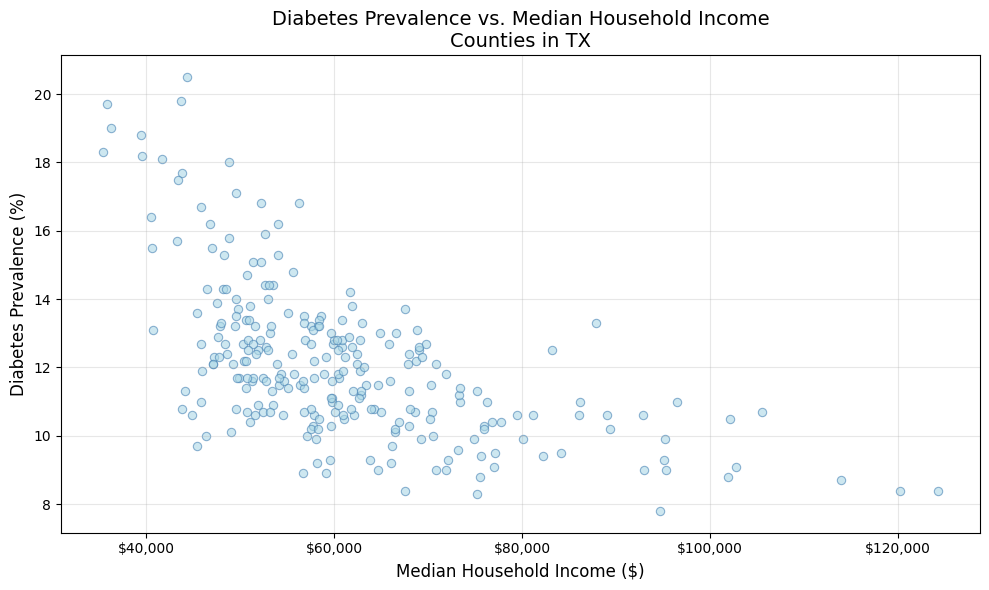

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    state_data[INCOME_COL],
    state_data[DIABETES_COL] * 100,  # Convert proportion to percentage
    alpha=0.6,
    edgecolors="steelblue",
    facecolors="lightblue",
    linewidths=0.8,
)

ax.set_xlabel("Median Household Income ($)", fontsize=12)
ax.set_ylabel("Diabetes Prevalence (%)", fontsize=12)
ax.set_title(
    f"Diabetes Prevalence vs. Median Household Income\n"
    f"Counties in {STATE}",
    fontsize=14,
)

# Format the x-axis labels as dollar amounts.
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What Do You See?

If your environment is set up correctly, you should see a scatter plot showing a
downward trend: counties with higher household incomes tend to have lower diabetes
rates. This negative relationship is a pattern that public health researchers have
documented extensively — income is one of the strongest social determinants of health.

But notice that the dots don't fall on a perfect line. Some lower-income counties have
relatively low diabetes rates, and some higher-income counties have rates higher than
you might expect. In the sections that follow, we'll learn how to quantify this
relationship using regression, measure how well our model fits, and understand why
no single factor tells the whole story.

### Workbench Check: Summary

If you made it this far without errors, your environment is ready. Here's what we confirmed:

1. **pandas** can load data from a remote URL
2. **matplotlib** can render charts in your notebook
3. **scikit-learn** is installed (we'll use it starting in Section 3.3)
4. You can download and work with the County Health Rankings dataset

In the next section, we'll dig deeper into this same dataset to understand how
statisticians describe and summarize population health data.